##Bulid A Basic Chatbot Using LangGraph

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from dotenv import load_dotenv
from groq import Groq
from langchain.chat_models import init_chat_model
import os

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key or groq_api_key.lower() in {"your_groq_api_key", "your-api-key"}:
    raise RuntimeError(
        "Set a valid GROQ_API_KEY in the .env file before creating the chat model."
    )

groq_client = Groq(api_key=groq_api_key)
available_models = {model.id for model in groq_client.models.list().data}
preferred_models = (
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "openai/gpt-oss-20b",
)
model_name = next(
    (model for model in preferred_models if model in available_models),
    None,
)
if model_name is None:
    raise RuntimeError(
        f"This GROQ_API_KEY cannot access a supported chat model. Available models: "
        f"{sorted(available_models)}"
    )

llm = init_chat_model(
    model_name,
    model_provider="groq",
    api_key=groq_api_key,
)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CF7310D940>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CF7310C830>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

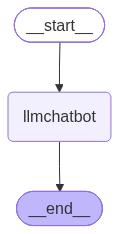

In [8]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages": [{"role": "user", "content": "Hi"}]})

In [10]:
response["messages"][-1].content

'Hello! 👋 How can I help you today?'

In [11]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hi How are you?"}]}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I’m just a bunch of code, but I’m functioning perfectly—thanks for asking. How can I help you today?


##Chatbot With Tools

In [12]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch

load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")
if not tavily_api_key or tavily_api_key.lower() in {"your_tavily_api_key", "your-api-key"}:
    raise RuntimeError(
        "Set a valid TAVILY_API_KEY in the .env file before using web search."
    )

tool = TavilySearch(max_results=2, tavily_api_key=tavily_api_key)
tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian C

In [13]:
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [14]:
tools=[tool,multiply]

In [15]:
llm_with_tool=llm.bind_tools(tools)

In [16]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CF7310D940>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CF7310C830>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

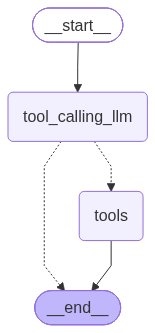

In [17]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [19]:
response['messages'][-1].content

'{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.hklaw.com/en/insights/publications/2026/09/holland-knight-health-dose-september-1-2026", "title": "Holland & Knight Health Dose: September 1, 2026", "content": "A leading electronic health record vendor announced several new AI capabilities in August 2026, including a tool designed to help clinicians prepare for patient visits by generating summaries from information already contained within the patient\'s chart. The company also highlighted additional AI-enabled functionality intended to support clinical documentation, patient communications and workflow management within the electronic health record environment. [...] In late July 2026, a leading consumer-facing AI platform launched a feature that allows U.S. users age 18 and older to connect personal health data and supported medical records directly to the platform. Users can receive explanations o

In [20]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_17a9125b-1a83-458b-b4f6-b34b9f487915)
 Call ID: fc_17a9125b-1a83-458b-b4f6-b34b9f487915
  Args:
    query: recent AI news 2026 September
    search_depth: basic
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.hklaw.com/en/insights/publications/2026/09/holland-knight-health-dose-september-1-2026", "title": "Holland & Knight Health Dose: September 1, 2026", "content": "A leading electronic health record vendor announced several new AI capabilities in August 2026, including a tool designed to help clinicians prepare for patient visits by generating

In [21]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

5 multiplied by 2 equals **10**.


In [22]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_95933a11-8289-441a-8dbb-0a863447aa3b)
 Call ID: fc_95933a11-8289-441a-8dbb-0a863447aa3b
  Args:
    query: recent AI news 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://seekingalpha.com/article/4944864-ai-robotics-in-2026-16-recent-developments-for-investors", "title": "AI And Robotics In 2026: 16 Recent Developments For Investors", "content": "AI agents are becoming more persistent and connected. Hark partnered with Nvidia, while private payments company Stripe agreed to acquire OpenRouter, connecting 

###ReAct Agent Architecture

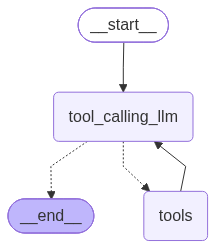

In [23]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_d77e4743-5b1e-41e1-a12f-35e9ccbed86d)
 Call ID: fc_d77e4743-5b1e-41e1-a12f-35e9ccbed86d
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bbc.com/news/world", "title": "World | Latest News & Updates", "content": "## Burundians rush to leave Kenya ahead of crackdown on unregistered traders\n\nKenya is due to start enforcing measures to restrict foreign nationals from operating small-scale businesses.\n\n## Features\n\n## A food safety officer has become a social media star in Ind

##Adding Memory In Agentic Graph

In [26]:
response=graph.invoke({"messages":"Hello my name is Zeeshan"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Zeeshan
================================== Ai Message ==================================

Hello Zeeshan! 👋 How can I help you today?


In [27]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don’t have that information—could you let me know your name?


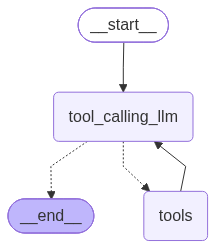

In [43]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Zeeshan"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Zeeshan', additional_kwargs={}, response_metadata={}, id='c1274104-71c6-475f-aa7a-520d496962e5'),
  AIMessage(content='Hello Zeeshan! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond politely, maybe ask for a question. No tool usage needed.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 349, 'total_tokens': 393, 'completion_time': 0.050557829, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.022292135, 'prompt_tokens_details': None, 'queue_time': 0.345794723, 'total_time': 0.072849964}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3023a70d60', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08b2a-527f-73a1-9ec8-609e0d4a174b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 349, 'output_tokens': 44, 'total_tokens': 393, '

In [45]:
response['messages'][-1].content

'Hello Zeeshan! Nice to meet you. How can I help you today?'

In [46]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Zeeshan.


In [47]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember. Your name is Zeeshan.


##Streaming

In [48]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [49]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

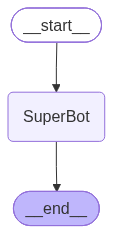

In [50]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [51]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Zeeshan And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Zeeshan And I like cricket', additional_kwargs={}, response_metadata={}, id='571dca9b-2655-432d-b8e8-750bc6d76c51'),
  AIMessage(content='Hello Zeeshan! 👋 It’s great to meet you. Cricket is such a fascinating sport—do you play it, follow a particular team, or have a favorite player? Let me know what you’re most excited about!', additional_kwargs={'reasoning_content': 'User says: Hi, My name is Zeeshan and I like cricket. They just introduced themselves. We can respond in a friendly manner. They may want to talk about cricket. So respond with greeting and ask about cricket.'}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 83, 'total_tokens': 186, 'completion_time': 0.142029891, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.004557557, 'prompt_tokens_details': None, 'queue_time': 0.341863841, 'total_time': 0.146587448}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3

In [52]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Zeeshan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Zeeshan! 👋 Great to meet a fellow cricket enthusiast. Which teams or players do you follow most? And do you play any cricket yourself, or are you more into watching the matches?', additional_kwargs={'reasoning_content': 'User says: "Hi,My name is Zeeshan And I like cricket". We need to respond as a cricket expert. The user introduction. So respond with a friendly greeting, ask about their interest. Possibly mention cricket. Let\'s respond warmly, ask about favorite teams.'}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 83, 'total_tokens': 189, 'completion_time': 0.145379863, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.004028902, 'prompt_tokens_details': None, 'queue_time': 0.311517527, 'total_time': 0.149408765}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_37c9245f64', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': '

In [53]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Zeeshan And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Zeeshan And I like cricket', additional_kwargs={}, response_metadata={}, id='35bfb2fd-11ff-41d4-ab4e-9044613944c0'), AIMessage(content='Hey Zeeshan! 👋 Great to meet a fellow cricket enthusiast. Which teams or players do you follow most? And do you play any cricket yourself, or are you more into watching the matches?', additional_kwargs={'reasoning_content': 'User says: "Hi,My name is Zeeshan And I like cricket". We need to respond as a cricket expert. The user introduction. So respond with a friendly greeting, ask about their interest. Possibly mention cricket. Let\'s respond warmly, ask about favorite teams.'}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 83, 'total_tokens': 189, 'completion_time': 0.145379863, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.004028902, 'prompt_tokens_details': None, 'queue_time': 0.311517527, 'total_time': 0.149408765}, 'model_name': 'openai/gpt-

In [54]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Zeeshan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Zeeshan! 👋 Great to meet you. Cricket’s a fantastic sport—there’s so much to talk about, from nail‑biting finishes to legendary players.  \n\n- Which format do you enjoy most (Test, ODI, T20, or maybe domestic leagues like IPL or BBL)?  \n- Do you have a favorite team or player?  \n- Any memorable matches or moments that stand out to you?  \n\nFeel free to share—let’s dive into the world of cricket together! 🏏', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Zeeshan And I like cricket". They greet, say name, mention liking cricket. We should respond with friendly greeting, ask about cricket preferences, maybe ask about favorite teams, players. We should keep it engaging. Probably ask what they like about cricket, any favorite players or matches, maybe ask about their favorite cricketing country. Also we should respond in a friendly manner. The user hasn\'t asked a question; we can respond with an introduction an

In [55]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Zeeshan And I like cricket', additional_kwargs={}, response_metadata={}, id='29d3f4e8-3bc5-49db-aa2d-a3c0a7b1142f'), AIMessage(content='Hey Zeeshan! 👋 Great to meet you. Cricket’s a fantastic sport—there’s so much to talk about, from nail‑biting finishes to legendary players.  \n\n- Which format do you enjoy most (Test, ODI, T20, or maybe domestic leagues like IPL or BBL)?  \n- Do you have a favorite team or player?  \n- Any memorable matches or moments that stand out to you?  \n\nFeel free to share—let’s dive into the world of cricket together! 🏏', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Zeeshan And I like cricket". They greet, say name, mention liking cricket. We should respond with friendly greeting, ask about cricket preferences, maybe ask about favorite teams, players. We should keep it engaging. Probably ask what they like about cricket, any favorite players or matches, maybe ask about their favorit

In [56]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Zeeshan and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Zeeshan and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a08b2b-7c70-7b80-acf3-cd45a7091a36', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Zeeshan and I like to play cricket', additional_kwargs={}, response_metadata={}, id='21767a43-0ffe-4550-b16e-7c7f6f6b646c')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a08b2b-7c72-7b92-9ee0-3c725bf8fda1', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:97133dd6-408d-8a2c-c0f0-ed31e86897e2'}, 'parent_ids': ['01a08b2b-7c70-7b80-acf3-cd45a7091a36']}
{'event': 'on_chat_model_start', 'data': {'input': {'messag